In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [3]:
X = pd.read_csv("../data/processed/scaled_features.csv")

In [4]:
X.head()

,price,area,bedrooms,stories,parking,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,4.566365,1.046726,1.403419,1.378217,1.517692,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.804941,-0.844888,-0.696429
1,4.004484,1.757010,1.403419,2.532024,2.679409,0.405623,-0.465315,-0.734539,-0.219265,1.472618,-0.554035,-0.844888,-0.696429
2,4.004484,2.218232,0.047278,0.224410,1.517692,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.804941,1.183588,-0.696429
3,3.985755,1.083624,1.403419,0.224410,2.679409,0.405623,-0.465315,1.361397,-0.219265,1.472618,1.804941,-0.844888,-0.696429
4,3.554979,1.046726,1.403419,0.224410,1.517692,0.405623,2.149083,1.361397,-0.219265,1.472618,-0.554035,-0.844888,-0.696429


In [5]:
inertia = []

k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(model.inertia_)

c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

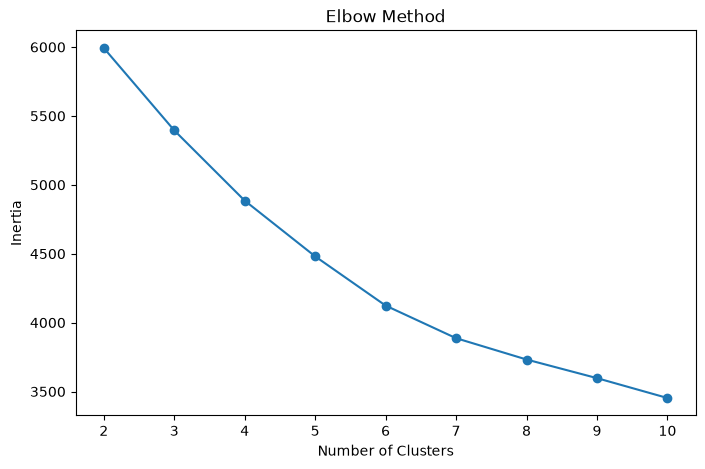

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [7]:
silhouette_scores = []

for k in range(2, 11):
     
     model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
     )

     labels = model.fit_predict(X)

     score = silhouette_score(
        X,
        labels
     )

     silhouette_scores.append(score)

c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memor

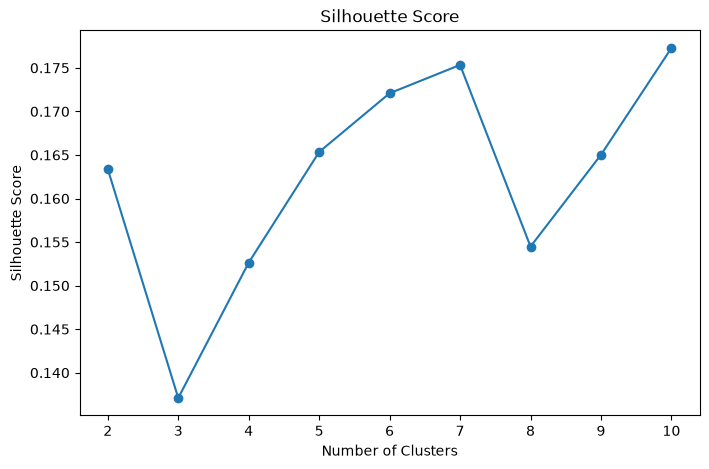

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [10]:
optimal_k = 10

kmeans = KMeans(
    n_clusters = optimal_k,
    random_state = 42,
    n_init = 10
)

kmeans_labels = kmeans.fit_predict(X)

c:\Users\Acer\.conda\envs\co\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [11]:
df = pd.read_csv("../data/raw/Housing.csv")

In [12]:
df["kmeans_cluster"] = kmeans_labels

In [13]:
df["kmeans_cluster"].value_counts()

kmeans_cluster
2    90
5    88
6    68
0    61
3    50
7    45
1    45
9    40
8    33
4    25
Name: count, dtype: int64

In [14]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,kmeans_cluster
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,7
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,7
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,6


### Cluster profiling

In [15]:
cluster_profile = df.groupby(
    "kmeans_cluster"
)[
    [
        "price",
        "area",
        "bedrooms",
        "stories",
        "parking"
    ]
].mean()

cluster_profile

,price,area,bedrooms,stories,parking
kmeans_cluster,,,,,
0,7.067696e+06,6364.672131,3.344262,3.540984,1.016393
1,4.714741e+06,4195.044444,2.933333,1.822222,0.333333
2,3.127639e+06,4296.422222,2.488889,1.366667,0.300000
3,4.351760e+06,4132.680000,2.940000,1.680000,0.660000
4,5.559960e+06,5059.280000,3.120000,1.880000,0.960000
5,4.182023e+06,4822.125000,2.988636,1.670455,0.784091
6,5.822816e+06,6060.955882,3.102941,1.602941,0.838235
7,6.782067e+06,9116.911111,3.133333,1.444444,1.600000
8,3.849141e+06,3665.545455,3.212121,1.757576,0.303030


In [16]:
import joblib

joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

joblib.dump(silhouette_scores,"../models/silhouette_scores.pkl")

['../models/silhouette_scores.pkl']